<h1>Q1</h1>

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('D:\sara\Quera_AI_Engineer\Quera Project_1\Quera-Project-1\data\Divar.csv')
iran_city_classification = pd.read_csv('D:\sara\Quera_AI_Engineer\Quera Project_1\Quera-Project-1\data\iran_city_classification.csv')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19712\1798292301.py:1: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('D:\sara\Quera_AI_Engineer\Quera Project_1\Quera-Project-1\data\Divar.csv')


In [3]:
iran_city_classification.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   نام شهر    240 non-null    object
 1   دسته‌بندی  240 non-null    object
dtypes: object(2)
memory usage: 3.9+ KB


In [4]:
iran_city_classification.head(5)

,نام شهر,دسته‌بندی
0,karaj,کلان‌شهر
1,tehran,کلان‌شهر
2,mashhad,کلان‌شهر
3,ahvaz,کلان‌شهر
4,kermanshah,کلان‌شهر


In [5]:
# Residential categories
target_categories = ["residential-sell", "residential-rent"]

df = train[
    train["cat2_slug"].isin(target_categories)
].copy()

# Keep only the required columns
df = df[
    [
        "city_slug",
        "building_size"
    ]
]

# Remove missing values
df = df.dropna(subset=["city_slug", "building_size"])

# Convert building_size to numeric (if necessary)
df["building_size"] = pd.to_numeric(df["building_size"], errors="coerce")
df = df.dropna(subset=["building_size"])


df = df.merge(
    iran_city_classification,
    left_on="city_slug",
    right_on="نام شهر",
    how="left"
)

In [6]:
df.head()

,city_slug,building_size,نام شهر,دسته‌بندی
0,tehran,60.0,tehran,کلان‌شهر
1,tehran,132.0,tehran,کلان‌شهر
2,mashhad,115.0,mashhad,کلان‌شهر
3,ahvaz,100.0,ahvaz,کلان‌شهر
4,tehran,100.0,tehran,کلان‌شهر


In [7]:
df["دسته‌بندی"].value_counts(dropna=False)

شهر کوچک    416564
کلان‌شهر    388460
NaN          30186
Name: دسته‌بندی, dtype: int64

In [8]:
df = df.dropna(subset=["دسته‌بندی"])

In [9]:
df["دسته‌بندی"].value_counts()

شهر کوچک    416564
کلان‌شهر    388460
Name: دسته‌بندی, dtype: int64

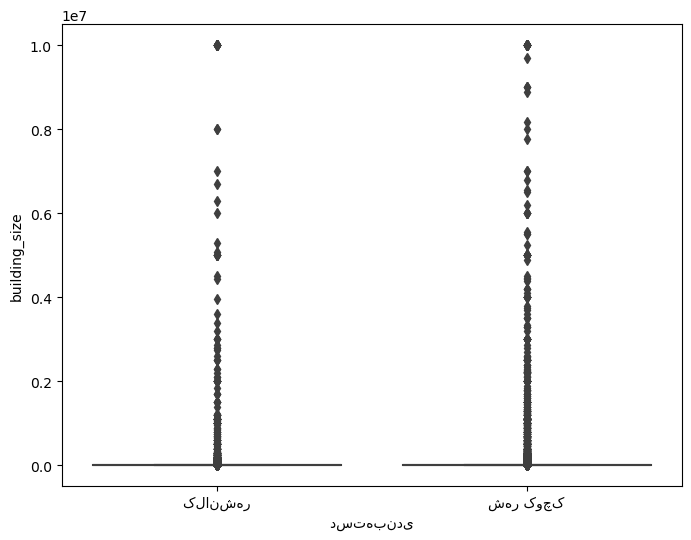

In [12]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="دسته‌بندی",
    y="building_size"
)

plt.show()

In [13]:
metro_area = df.loc[
    df["دسته‌بندی"] == "کلان‌شهر",
    "building_size"
]

small_area = df.loc[
    df["دسته‌بندی"] == "شهر کوچک",
    "building_size"
]

In [14]:
# ==========================================
# Section X: Building Size Quantiles
# ==========================================

quantiles = [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]

print("Metro Cities")
print(metro_area.quantile(quantiles))

print("\n" + "="*50 + "\n")

print("Small Cities")
print(small_area.quantile(quantiles))

Metro Cities
0.500       100.0
0.750       147.0
0.900       225.0
0.950       353.0
0.990      1500.0
0.995      4200.0
0.999    120000.0
Name: building_size, dtype: float64


Small Cities
0.500        110.000
0.750        183.000
0.900        360.000
0.950        800.000
0.990       8000.000
0.995      33265.355
0.999    1000000.000
Name: building_size, dtype: float64


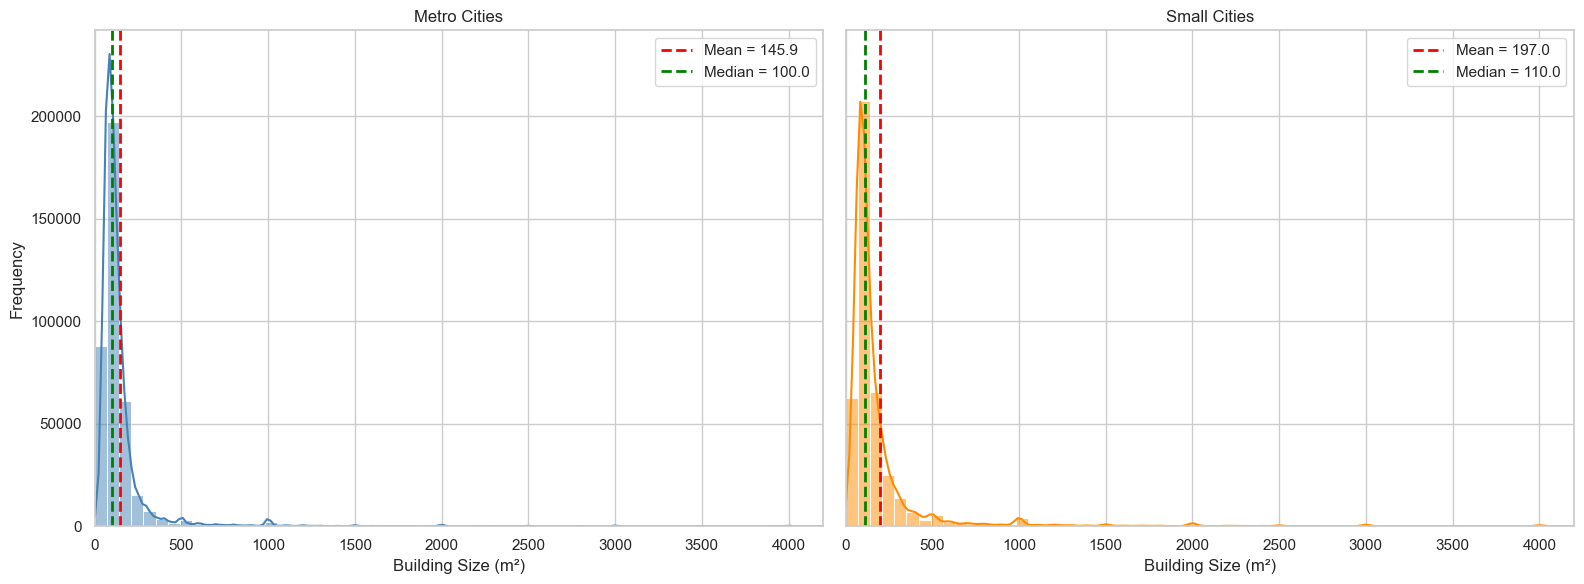

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Section 1: General Configuration
# ==========================================
sns.set_theme(style="whitegrid")

# Use the 99th percentile only for visualization
upper_limit = df["building_size"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# ==========================================
# Section 2: Metro Cities
# ==========================================
metro_plot = metro_area[metro_area <= upper_limit]

sns.histplot(
    metro_plot,
    bins=60,
    kde=True,
    color="steelblue",
    ax=axes[0]
)

axes[0].axvline(
    metro_plot.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {metro_plot.mean():.1f}"
)

axes[0].axvline(
    metro_plot.median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {metro_plot.median():.1f}"
)

axes[0].set_xlim(0, upper_limit)
axes[0].set_title("Metro Cities")
axes[0].set_xlabel("Building Size (m²)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# ==========================================
# Section 3: Small Cities
# ==========================================
small_plot = small_area[small_area <= upper_limit]

sns.histplot(
    small_plot,
    bins=60,
    kde=True,
    color="darkorange",
    ax=axes[1]
)

axes[1].axvline(
    small_plot.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {small_plot.mean():.1f}"
)

axes[1].axvline(
    small_plot.median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {small_plot.median():.1f}"
)

axes[1].set_xlim(0, upper_limit)
axes[1].set_title("Small Cities")
axes[1].set_xlabel("Building Size (m²)")
axes[1].legend()

# ==========================================
# Section 4: Display
# ==========================================
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd
from scipy.stats import shapiro

# ---------------------------------------------------------
# 0. Normality Check (Shapiro-Wilk Test)
# ---------------------------------------------------------
# The Shapiro-Wilk test checks whether a sample comes from
# a normally distributed population.
# H0: The data is normally distributed.
# H1: The data is NOT normally distributed.

# IMPORTANT: Shapiro-Wilk is unreliable on very large samples
# (typically n > 5000), because it becomes hypersensitive to
# even tiny, practically insignificant deviations from normality
# and will almost always reject H0.
# Solution: run the test on a random subsample (n=5000 at most).


# ---------------------------------------------------------
# 1. Data Preprocessing & Filtering
# ---------------------------------------------------------

# Calculate the 99th percentile as the upper limit
upper_limit = df["building_size"].quantile(0.99)

# Filter the dataset: minimum 10 sq meters up to the 99th percentile
df_filtered = df[(df['building_size'] >= 10) & (df['building_size'] <= upper_limit)]

# Separate the dataset into two distinct groups based on city classification
big_cities = df_filtered.loc[df_filtered["دسته‌بندی"] == "کلان‌شهر", "building_size"]
small_cities = df_filtered.loc[df_filtered["دسته‌بندی"] == "شهر کوچک", "building_size"]

SHAPIRO_SAMPLE_SIZE = 5000
alpha = 0.05

for group_name, group_data in [("Big Cities (کلان‌شهر)", big_cities),
                                 ("Small Cities (شهر کوچک)", small_cities)]:

    # Draw a random subsample if the group is larger than the threshold
    if len(group_data) > SHAPIRO_SAMPLE_SIZE:
        sample = group_data.sample(n=SHAPIRO_SAMPLE_SIZE, random_state=42)
        note = f"(subsample of {SHAPIRO_SAMPLE_SIZE} from {len(group_data)} observations)"
    else:
        sample = group_data
        note = f"(full sample, n={len(group_data)})"

    stat, p_val = shapiro(sample)

    print(f"\n--- Shapiro-Wilk Test: {group_name} {note} ---")
    print(f"  W-statistic : {stat:.4f}")
    print(f"  P-value     : {p_val:.4e}")

    if p_val < alpha:
        print("  Result: Reject H0 → Data is NOT normally distributed.")
        print("  → A non-parametric test (e.g. Mann-Whitney U) is more appropriate.")
    else:
        print("  Result: Fail to reject H0 → Data appears normally distributed.")
        print("  → Parametric tests (e.g. T-test) can be used.")


--- Shapiro-Wilk Test: Big Cities (کلان‌شهر) (subsample of 5000 from 385688 observations) ---
  W-statistic : 0.3229
  P-value     : 0.0000e+00
  Result: Reject H0 → Data is NOT normally distributed.
  → A non-parametric test (e.g. Mann-Whitney U) is more appropriate.

--- Shapiro-Wilk Test: Small Cities (شهر کوچک) (subsample of 5000 from 409338 observations) ---
  W-statistic : 0.3689
  P-value     : 0.0000e+00
  Result: Reject H0 → Data is NOT normally distributed.
  → A non-parametric test (e.g. Mann-Whitney U) is more appropriate.




Normality Check & Test Selection

Shapiro-Wilk Test Results
The Shapiro-Wilk normality test was applied to a random subsample of 5,000 observations from each group. Results showed that both groups significantly deviate from a normal distribution (W = 0.32 and W = 0.36, p ≈ 0.0000 for both), leading to rejection of the normality assumption in each case.
Which Test to Use & Why
Given the non-normality of both groups, the statistically appropriate choice is a non-parametric test — specifically the Mann-Whitney U test — since it makes no assumption about the underlying distribution and compares groups based on rank ordering rather than means.
However, given that both groups contain very large sample sizes (n = 385,688 for metro cities and n = 409,338 for small cities), the Two-Sample Welch's T-test also remains valid. This is justified by the Central Limit Theorem (CLT): when sample sizes are sufficiently large, the sampling distribution of the mean converges to normality regardless of the shape of the original data distribution. In practice, with samples of this magnitude and continuesly values, the T-test is highly robust to skewness and non-normality.
Therefore, both tests will be conducted in parallel:

The Mann-Whitney U test as the statistically rigorous non-parametric approach
The Welch's Two Sample T-test as a robust parametric complement, justified by the very large sample sizes

Convergence of results across both tests will strengthen the reliability of the final conclusion.

H0​: μ metro ​≥ μ small​

H1​: μ metro ​< μ small​

α = 0.05



In [22]:
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, ks_2samp

# ---------------------------------------------------------
# 1. Data Preprocessing & Filtering
# ---------------------------------------------------------
# Calculate the 99th percentile as the upper limit
upper_limit = df["building_size"].quantile(0.99)

# Filter the dataset: minimum 10 sq meters up to the 99th percentile
df_filtered = df[(df['building_size'] >= 10) & (df['building_size'] <= upper_limit)]

# Separate the dataset into two distinct groups based on city classification
big_cities = df_filtered.loc[df_filtered["دسته‌بندی"] == "کلان‌شهر", "building_size"]
small_cities = df_filtered.loc[df_filtered["دسته‌بندی"] == "شهر کوچک", "building_size"]

# ---------------------------------------------------------
# 2. Statistical Hypothesis Testing (Welch's T-test)
# ---------------------------------------------------------
t_stat, p_value = ttest_ind(
    a=big_cities,
    b=small_cities,
    equal_var=False,
    alternative='less'
)

print(f"Upper Limit (99th percentile): {upper_limit}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

alpha = 0.05
if p_value < alpha:
    print("Result: Reject the Null Hypothesis (H0).")
else:
    print("Result: Fail to reject the Null Hypothesis (H0).")

# ---------------------------------------------------------
# 3. Non-Parametric Test #1: Mann-Whitney U Test
# ---------------------------------------------------------
# This is the standard non-parametric counterpart to the independent-samples
# t-test (it does not assume normality, which fits our skewed data).
# It tests whether values from one group tend to be stochastically smaller
# (or larger) than values from the other group, rather than comparing means directly.
u_stat, p_value_mw = mannwhitneyu(
    x=big_cities,
    y=small_cities,
    alternative='less'   # consistent with the t-test's alternative hypothesis
)

print("\n--- Mann-Whitney U Test ---")
print(f"U-statistic: {u_stat:.4f}")
print(f"P-value: {p_value_mw:.4e}")

if p_value_mw < alpha:
    print("Result: Reject the Null Hypothesis (H0).")
else:
    print("Result: Fail to reject the Null Hypothesis (H0).")



Upper Limit (99th percentile): 4200.0
T-statistic: -81.2825
P-value: 0.0000e+00
Result: Reject the Null Hypothesis (H0).

--- Mann-Whitney U Test ---
U-statistic: 69171426965.5000
P-value: 0.0000e+00
Result: Reject the Null Hypothesis (H0).


## 📊 Test Results & Conclusion

### Results Summary

<table>
  <thead>
    <tr>
      <th>Test</th>
      <th>Type</th>
      <th>Statistic</th>
      <th>P-value</th>
      <th>Decision</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Welch's T-test</td>
      <td>Parametric</td>
      <td>T = −81.28</td>
      <td>p &lt; 0.0001</td>
      <td>✅ Reject H₀</td>
    </tr>
    <tr>
      <td>Mann-Whitney U</td>
      <td>Non-Parametric</td>
      <td>U = 69,171,426,965.5</td>
      <td>p &lt; 0.0001</td>
      <td>✅ Reject H₀</td>
    </tr>
  </tbody>
</table>

---

### Hypotheses

$$H_0: \mu_{\text{metro}} \geq \mu_{\text{small}}$$

$$H_1: \mu_{\text{metro}} < \mu_{\text{small}}$$

$$\alpha = 0.05$$

---

### Conclusion

Both tests — the parametric **Welch's T-test** and the non-parametric **Mann-Whitney U test** — unanimously reject the null hypothesis at the 0.05 significance level. The convergence of results across both approaches substantially reinforces the reliability of this finding.

> **The mean residential unit size in metropolitan cities is statistically significantly smaller than the mean residential unit size in small cities.**

In practical terms, homes in small cities tend to be larger on average than homes in metropolitan areas. This pattern likely reflects fundamental differences in urban real estate markets:

<ul>
  <li><strong>Higher land prices</strong> in metropolitan areas push developers toward smaller, more affordable units.</li>
  <li><strong>Population density and space constraints</strong> in large cities limit the feasibility of building larger residential units.</li>
  <li><strong>Lower land costs and fewer space restrictions</strong> in small cities allow for the construction of larger dwellings.</li>
</ul>